In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # for data validation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [60]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\DATASCIENCE\\DATASETS\\salary_data.csv")

In [61]:
df

,ExperienceYears,Age,Education,Role,Location,SkillsCount,Salary
0,13.93,42.7,Bachelors,Backend Developer,Gurugram,13,1586084
1,7.90,32.1,Bachelors,Software Engineer,Noida,14,1215682
2,15.45,41.5,Bachelors,Frontend Developer,Pune,16,1541007
3,12.55,30.3,Bachelors,Backend Developer,Bengaluru,14,1874288
4,1.70,23.2,Bachelors,ML Engineer,Bengaluru,5,943390
...,...,...,...,...,...,...,...
595,5.00,29.6,Bachelors,Data Scientist,Mumbai,8,1291556
596,12.65,34.7,Diploma,Backend Developer,Remote,15,1331575
597,11.41,36.2,Bachelors,Data Scientist,Remote,8,1553904
598,17.67,37.9,Bachelors,Backend Developer,Gurugram,14,1932938


In [62]:
df.head(10)

,ExperienceYears,Age,Education,Role,Location,SkillsCount,Salary
0,13.93,42.7,Bachelors,Backend Developer,Gurugram,13,1586084
1,7.90,32.1,Bachelors,Software Engineer,Noida,14,1215682
2,15.45,41.5,Bachelors,Frontend Developer,Pune,16,1541007
3,12.55,30.3,Bachelors,Backend Developer,Bengaluru,14,1874288
4,1.70,23.2,Bachelors,ML Engineer,Bengaluru,5,943390
5,17.56,41.7,Masters,Data Scientist,Remote,12,2321682
6,13.70,35.5,Diploma,Data Analyst,Noida,13,1343778
7,14.15,41.3,Diploma,Backend Developer,Pune,10,1672647
8,2.31,33.3,Bachelors,Frontend Developer,Pune,6,833671
9,8.11,29.6,Masters,ML Engineer,Bengaluru,9,1640603


In [63]:
df.describe()

,ExperienceYears,Age,SkillsCount,Salary
count,600.000000,600.000000,600.00000,6.000000e+02
mean,8.927583,33.826167,9.48000,1.372388e+06
std,5.169945,5.971023,3.37717,4.108977e+05
min,0.100000,20.000000,1.00000,3.973410e+05
25%,4.260000,29.200000,7.00000,1.035412e+06
50%,8.995000,33.900000,9.00000,1.383819e+06
75%,13.502500,38.700000,12.00000,1.694363e+06
max,17.980000,49.500000,18.00000,2.478407e+06


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ExperienceYears  600 non-null    float64
 1   Age              600 non-null    float64
 2   Education        600 non-null    object 
 3   Role             600 non-null    object 
 4   Location         600 non-null    object 
 5   SkillsCount      600 non-null    int64  
 6   Salary           600 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 32.9+ KB


In [65]:
df.shape

(600, 7)

In [66]:
df.isna().sum()

ExperienceYears    0
Age                0
Education          0
Role               0
Location           0
SkillsCount        0
Salary             0
dtype: int64

In [67]:
from sklearn.preprocessing import LabelEncoder

In [68]:
le = LabelEncoder()

In [69]:
df['Education'] = le.fit_transform(df['Education'])

In [70]:
df['Education']

0      0
1      0
2      0
3      0
4      0
      ..
595    0
596    1
597    0
598    0
599    2
Name: Education, Length: 600, dtype: int64

In [71]:
df['Role'] = le.fit_transform(df['Role'])

In [72]:
df['Role']

0      0
1      5
2      3
3      0
4      4
      ..
595    2
596    0
597    2
598    0
599    5
Name: Role, Length: 600, dtype: int64

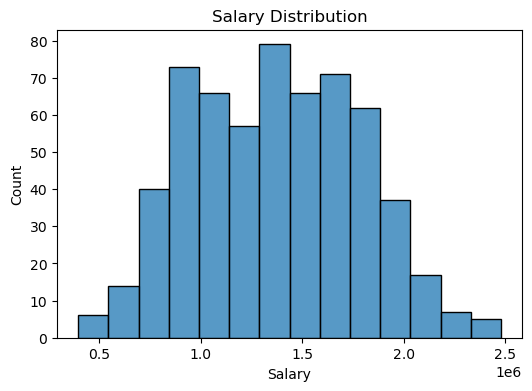

In [73]:
plt.figure(figsize=(6,4))
sns.histplot(df["Salary"])
plt.title("Salary Distribution")
plt.show()

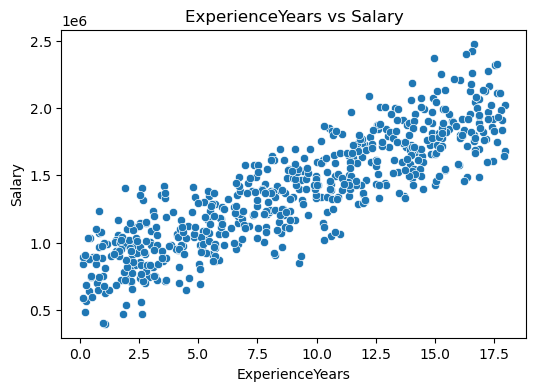

In [74]:
plt.figure(figsize=(6,4))
sns.scatterplot(x = 'ExperienceYears' ,y = 'Salary', data = df)
plt.title("ExperienceYears vs Salary")
plt.show()

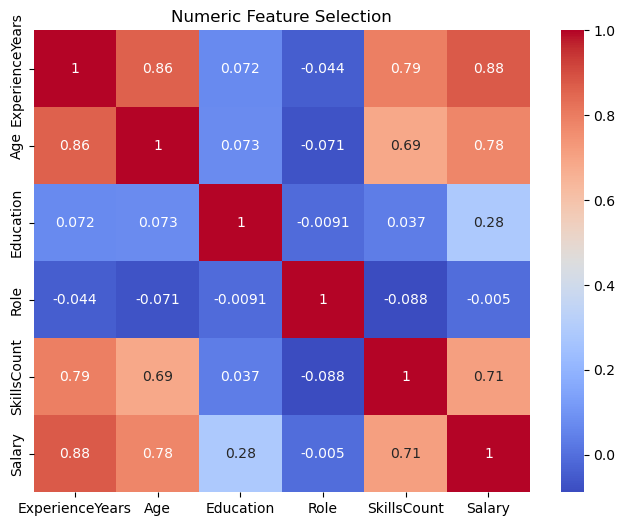

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Numeric Feature Selection')
plt.show()

In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
X = df[['ExperienceYears', 'Education', 'Role', 'SkillsCount']]
y = df['Salary']

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [79]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [80]:
y_pred = model.predict(X_test)
y_pred

array([1454327.29739987, 1789321.20116074, 1489455.63909723,
       1500802.16995694, 1942429.76072587, 1403962.36285392,
       1167269.38400968, 1508272.3350794 , 1566773.95237024,
        937774.20847082, 1629813.05412757, 1222461.65311579,
       1932333.18696399,  886770.50156332, 1855813.7539723 ,
       1829443.83346385, 1684713.84752856,  940903.82803935,
       1900174.86372377, 1548688.06869907, 1783605.67204106,
       1030134.58966477,  930188.10261234, 1642690.83199849,
       1042338.49497907, 1886365.73772635, 1932774.07798876,
        677187.77688628, 1212299.57941924, 1283594.46594458,
       1014326.17362192,  934722.84266435, 1771831.00398396,
        997421.49589104,  802632.43055375, 1002918.42291769,
       1427153.25535249,  966576.93637206, 1053563.17940118,
       1369417.47937518, 1636278.49070306, 1503964.16404929,
       1222641.38173199, 1106883.3173496 , 1627289.83239677,
       1299995.40719473,  868828.72076166, 1729111.17627815,
       1707411.18933813,

In [81]:
from sklearn.metrics import r2_score, mean_squared_error

In [82]:
r2 = r2_score(y_test, y_pred)

In [83]:
r2

0.787618993837327

In [101]:
from sklearn.ensemble import RandomForestRegressor

In [102]:
X

,ExperienceYears,Education,Role,SkillsCount
0,13.93,0,0,13
1,7.90,0,5,14
2,15.45,0,3,16
3,12.55,0,0,14
4,1.70,0,4,5
...,...,...,...,...
595,5.00,0,2,8
596,12.65,1,0,15
597,11.41,0,2,8
598,17.67,0,0,14


In [103]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [104]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [105]:
y_pred = model.predict(X_test)
print("r2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

r2 Score: 0.8133807589203583
MSE: 29324219576.510986
